# Dynamic Pricing Optimization - Phase 4: Price Elasticity Analysis

This phase simulates price changes using the trained demand model and estimates elasticity.

## Phase 4 Goals
1. Load Phase 3 model artifacts
2. Build simulation context (latest row per store)
3. Simulate demand response for price multipliers
4. Estimate store-level elasticity
5. Find revenue-maximizing price by store
6. Save analytical outputs

In [ ]:
import os
import sys
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

sys.path.append(os.path.abspath('../src'))

from price_elasticity import (
    load_phase4_inputs,
    get_context_rows,
    simulate_price_response,
    estimate_store_elasticity,
    get_optimal_price_by_store,
    recommend_guardrailed_prices,
    save_phase4_outputs
)

print('Phase 4 imports loaded successfully.')

Phase 4 imports loaded successfully.


## 1. Load Model Artifacts and Phase 2 Data

In [2]:
df, model, scaler, metadata, feature_cols = load_phase4_inputs(
    data_path='../data/walmart_ml_ready.csv',
    model_path='../models/best_demand_model.joblib',
    scaler_path='../models/phase3_scaler.joblib',
    metadata_path='../models/phase3_metadata.json'
)

print(f'Data shape: {df.shape}')
print(f'Best model from metadata: {metadata["best_model"]}')
print(f'Feature count expected by model: {len(feature_cols)}')

Data shape: (6255, 34)
Best model from metadata: GradientBoosting
Feature count expected by model: 32


## 2. Build Simulation Context

In [3]:
context_df = get_context_rows(df, context='latest_per_store')
print(f'Context rows (stores): {len(context_df)}')
context_df[['Store', 'Date', 'Price']].head()

Context rows (stores): 45


,Store,Date,Price
0,1,2012-10-26,84.11
1,2,2012-10-26,86.40
2,3,2012-10-26,83.14
3,4,2012-10-26,81.32
4,5,2012-10-26,78.45


## 3. Simulate Price Response

In [4]:
price_grid = np.linspace(0.80, 1.20, 21)
sim_df = simulate_price_response(
    context_df=context_df,
    model=model,
    scaler=scaler,
    feature_cols=feature_cols,
    price_multipliers=price_grid
)

print(f'Simulation rows: {len(sim_df)}')
sim_df.head()

Simulation rows: 945


,Store,Date,Base_Sim_Price,Price_Multiplier,Simulated_Price,Predicted_Demand,Predicted_Revenue
0,1,2012-10-26,84.11,0.8,67.288,1.572757e+06,1.058277e+08
1,2,2012-10-26,86.40,0.8,69.120,1.889183e+06,1.305803e+08
2,3,2012-10-26,83.14,0.8,66.512,4.378470e+05,2.912208e+07
3,4,2012-10-26,81.32,0.8,65.056,2.232610e+06,1.452447e+08
4,5,2012-10-26,78.45,0.8,62.760,3.543072e+05,2.223632e+07


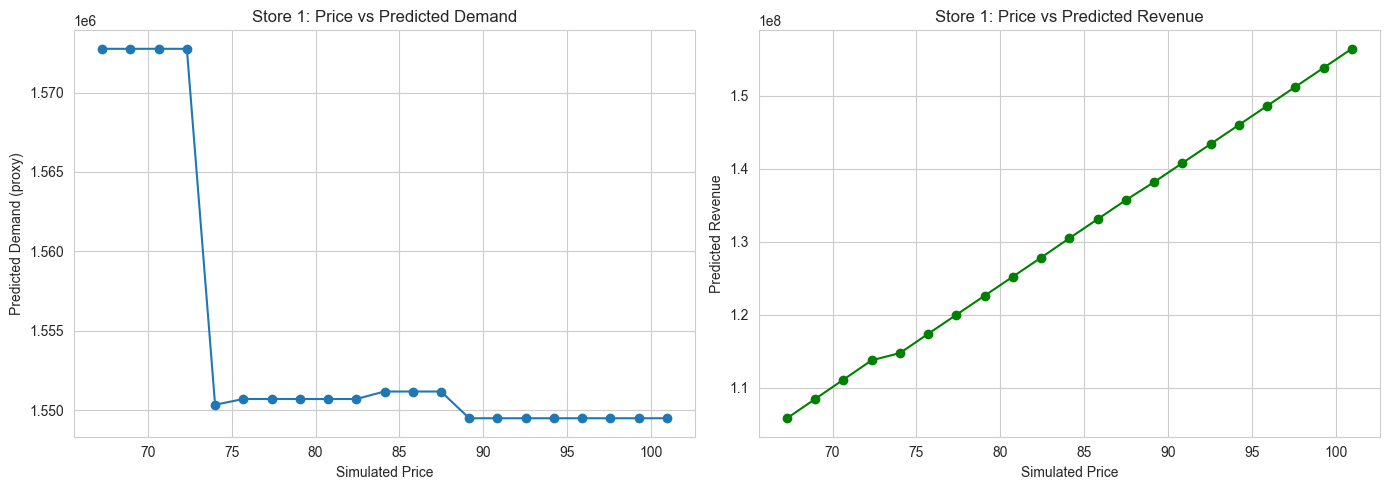

Saved: ../output/phase4_example_store_curves.png


In [5]:
# Example curve for a single store
example_store = int(sim_df['Store'].iloc[0])
curve = sim_df[sim_df['Store'] == example_store].sort_values('Simulated_Price')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(curve['Simulated_Price'], curve['Predicted_Demand'], marker='o')
axes[0].set_title(f'Store {example_store}: Price vs Predicted Demand')
axes[0].set_xlabel('Simulated Price')
axes[0].set_ylabel('Predicted Demand (proxy)')

axes[1].plot(curve['Simulated_Price'], curve['Predicted_Revenue'], marker='o', color='green')
axes[1].set_title(f'Store {example_store}: Price vs Predicted Revenue')
axes[1].set_xlabel('Simulated Price')
axes[1].set_ylabel('Predicted Revenue')

plt.tight_layout()
plt.savefig('../output/phase4_example_store_curves.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved: ../output/phase4_example_store_curves.png')

## 4. Estimate Elasticity and Optimize Price

In [ ]:
elasticity_df = estimate_store_elasticity(sim_df)
optimal_df = get_optimal_price_by_store(sim_df)
recommendation_df = recommend_guardrailed_prices(sim_df, elasticity_df)

print('Unconstrained optimum sample:')
display(optimal_df.head())
print('Guardrailed recommendation sample:')
display(recommendation_df.head())

(   Store  Elasticity  LogLog_Intercept
 0      1   -0.034598         14.409728
 1      2   -0.043807         14.633427
 2      3   -0.124032         13.507122
 3      4   -0.021182         14.706252
 4      5   -0.189900         13.557216,
    Store       Date  Base_Sim_Price  Price_Multiplier  Optimal_Price  \
 0      1 2012-10-26           84.11               1.2        100.932   
 1      2 2012-10-26           86.40               1.2        103.680   
 2      3 2012-10-26           83.14               1.2         99.768   
 3      4 2012-10-26           81.32               1.2         97.584   
 4      5 2012-10-26           78.45               1.2         94.140   
 
    Optimal_Demand  Optimal_Revenue  
 0    1.549488e+06     1.563930e+08  
 1    1.840546e+06     1.908278e+08  
 2    4.202336e+05     4.192586e+07  
 3    2.215043e+06     2.161528e+08  
 4    3.315977e+05     3.121660e+07  )

In [ ]:
print('Elasticity summary:')
print(elasticity_df['Elasticity'].describe())

print('\nUnconstrained optimal multiplier summary:')
print(optimal_df['Price_Multiplier'].describe())

print('\nGuardrailed recommended multiplier summary:')
print(recommendation_df['Recommended_Multiplier'].describe())

print('\nExpected revenue uplift summary (%):')
print(recommendation_df['Expected_Revenue_Change_Pct'].describe())

print('\nElasticity segment counts:')
print(recommendation_df['Elasticity_Segment'].value_counts())

Elasticity summary:
count    45.000000
mean     -0.035050
std       0.038356
min      -0.189900
25%      -0.043340
50%      -0.023506
75%      -0.010665
max      -0.004263
Name: Elasticity, dtype: float64

Optimal multiplier summary:
count    4.500000e+01
mean     1.200000e+00
std      4.491073e-16
min      1.200000e+00
25%      1.200000e+00
50%      1.200000e+00
75%      1.200000e+00
max      1.200000e+00
Name: Price_Multiplier, dtype: float64


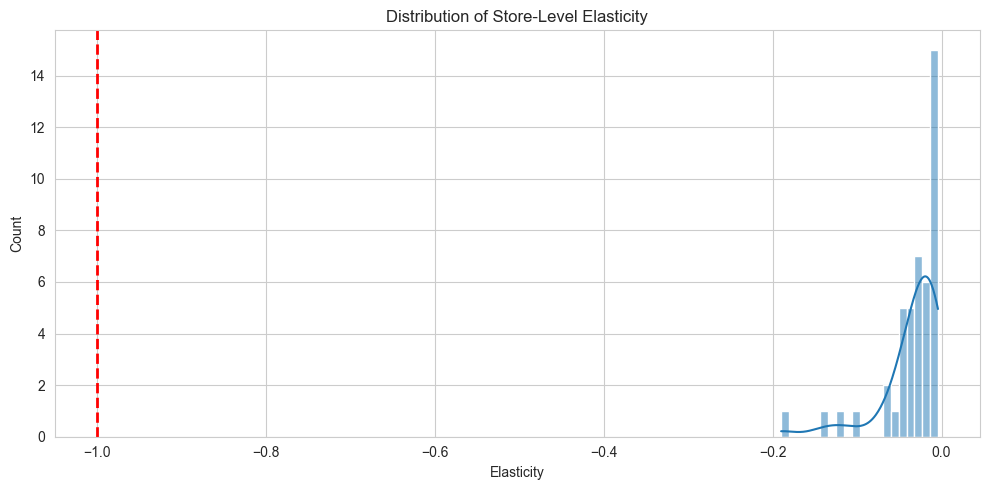

Saved: ../output/phase4_elasticity_distribution.png


In [8]:
plt.figure(figsize=(10, 5))
sns.histplot(elasticity_df['Elasticity'].dropna(), bins=20, kde=True)
plt.axvline(-1.0, color='red', linestyle='--', linewidth=2)
plt.title('Distribution of Store-Level Elasticity')
plt.xlabel('Elasticity')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('../output/phase4_elasticity_distribution.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved: ../output/phase4_elasticity_distribution.png')

D:\Temp\ipykernel_23904\2776548594.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_revenue, x='Store', y='Optimal_Revenue', palette='Blues_d')


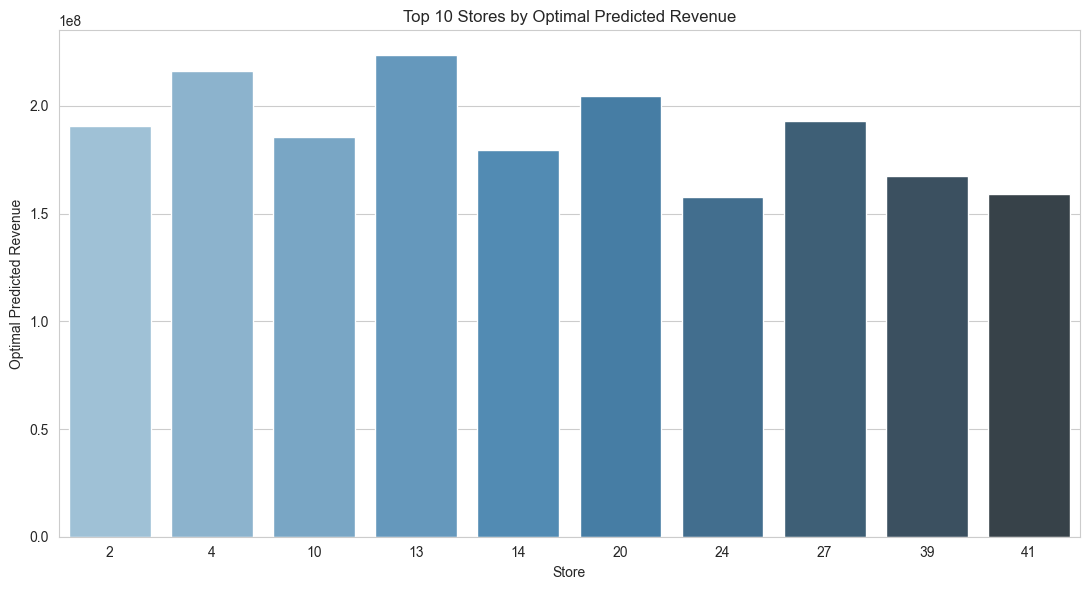

Saved: ../output/phase4_top_stores_optimal_revenue.png


In [ ]:
top_revenue = recommendation_df.sort_values('Recommended_Revenue', ascending=False).head(10)

plt.figure(figsize=(11, 6))
sns.barplot(data=top_revenue, x='Store', y='Recommended_Revenue', hue='Store', dodge=False, palette='Blues_d', legend=False)
plt.title('Top 10 Stores by Guardrailed Recommended Revenue')
plt.xlabel('Store')
plt.ylabel('Recommended Predicted Revenue')
plt.tight_layout()
plt.savefig('../output/phase4_top_stores_recommended_revenue.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved: ../output/phase4_top_stores_recommended_revenue.png')

## 5. Save Phase 4 Outputs

In [ ]:
saved = save_phase4_outputs(
    sim_df,
    elasticity_df,
    optimal_df,
    recommendation_df=recommendation_df,
    output_dir='../output'
)
print('Phase 4 tables saved:')
for k, v in saved.items():
    print(f'- {k}: {v}')

Phase 4 tables saved:
- simulation_csv: ../output\phase4_price_simulation_results.csv
- elasticity_csv: ../output\phase4_store_elasticity.csv
- optimal_prices_csv: ../output\phase4_optimal_prices_by_store.csv


## Phase 4 Summary

- Simulated demand response for each store across multiple price levels
- Estimated store-specific elasticity using log-log slope
- Selected optimal prices by maximizing predicted revenue
- Saved Phase 4 tables and visuals for reporting and Phase 5